In [3]:
import torch 
import torch.nn as nn
import torch.optim as optim

In [4]:
distance=torch.tensor([[0.0, 1.0, 2.0], [1.0, 0.0, 1.0], [2.0, 1.0, 0.0]],dtype=torch.float32)
time=torch.tensor([[0.0], [1.0], [2.0]],dtype=torch.float32)
print(distance)
print(time)


tensor([[0., 1., 2.],
        [1., 0., 1.],
        [2., 1., 0.]])
tensor([[0.],
        [1.],
        [2.]])


to feed it into the network , linear means single layer of neurons, 3 inputs and 1 output
print(model)
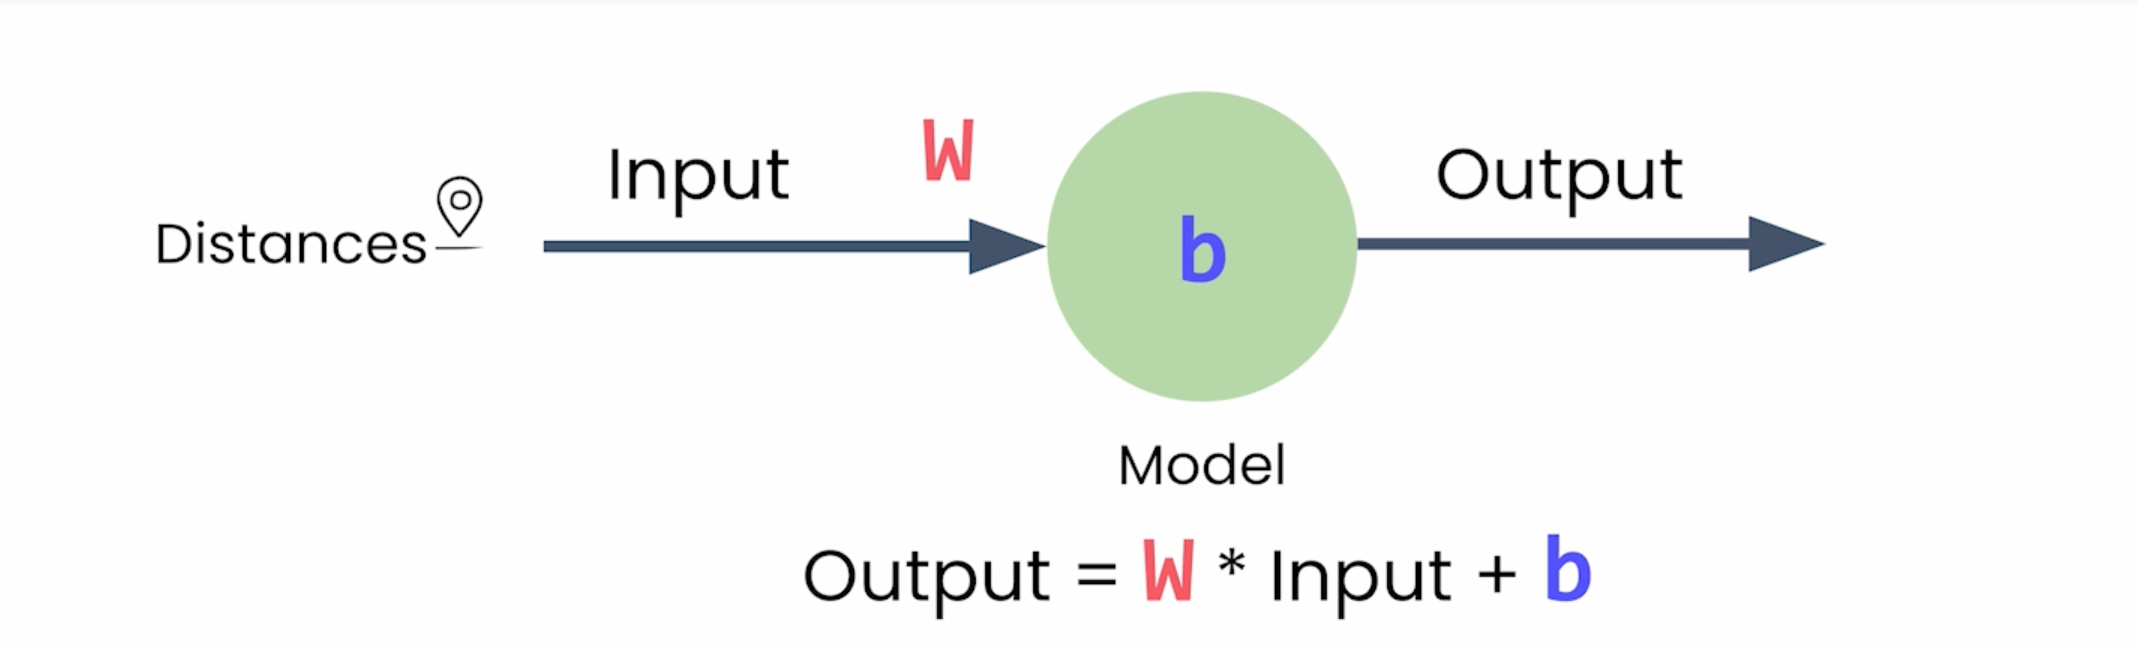

In [5]:
model=nn.Sequential(nn.Linear(3,1)) 
print(model)

Sequential(
  (0): Linear(in_features=3, out_features=1, bias=True)
)


to actually learn and correct it needs backpropagation so we use loss(how much wrong) and optimiser model(negative or positve adjustment and how much) with learning rate (how fast)

In [6]:
loss_function=nn.MSELoss()
learning_rate=0.1
optimizer=optim.SGD(model.parameters(),lr=learning_rate)


/Users/lakshitasenthikumar/.pyenv/versions/3.11.6/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


this is has to be done hundreds of times until we get the best loss , so each loop we call it epoch 

In [7]:
for epoch in range(100):
    optimizer.zero_grad()#to clear out value from prev training step
    outputs=model(distance)#predicting the output
    loss=loss_function(outputs,time)#loss - dif ference between predicted and actual value
    loss.backward()# computing the gradients
    optimizer.step()# update the w,b

In [8]:
with torch.no_grad():#means no training just inference so just forward pass
    test_distance=torch.tensor([[9.0, 10.0, 11.0]],dtype=torch.float32)
    pred_time=model(test_distance)
    print(pred_time)

tensor([[3.9016]])


Activation

this has straight line as pred which fails for complex problems so we try activation function

In [22]:
distance=torch.tensor([[0.7, 1.5, 2.0], [1.0, 5.0, 1.0], [6.0, 1.0, 1.0]],dtype=torch.float32)
time=torch.tensor([[0.9], [1.5], [9.3]],dtype=torch.float32)

In [23]:
model2=nn.Sequential(nn.Linear(3,5),nn.Sigmoid(),nn.Linear(5,1))
loss_function2=nn.MSELoss()
optimizer2=optim.SGD(model2.parameters(),lr=learning_rate)
for epoch in range(500):
    optimizer2.zero_grad()
    outputs=model2(distance)
    loss=loss_function2(outputs,time)
    loss.backward()
    optimizer2.step()
with torch.no_grad():
    test_distance=torch.tensor([[9.0, 10.0, 11.0]],dtype=torch.float32)
    pred_time=model2(test_distance)
    print(pred_time)

tensor([[0.0820]])


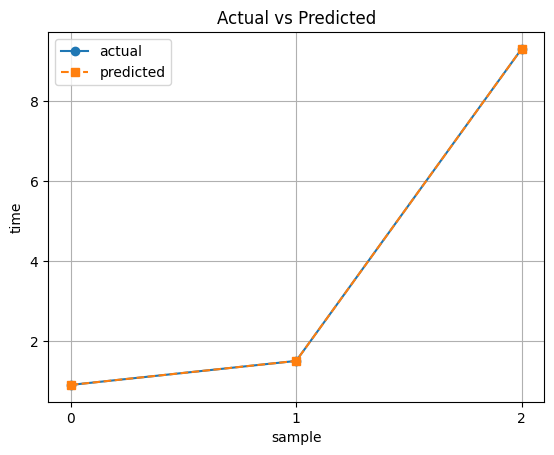

In [24]:
import matplotlib.pyplot as plt

actual = time.numpy().flatten()
predicted = outputs.detach().numpy().flatten()
indices = range(len(actual))

plt.figure()
plt.plot(indices, actual, 'o-', label='actual')
plt.plot(indices, predicted, 's--', label='predicted')
plt.xticks(indices)
plt.xlabel('sample')
plt.ylabel('time')
plt.title('Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
import sys
print(sys.executable)

/Users/lakshitasenthikumar/.pyenv/versions/3.11.6/bin/python
